# Лабораторна робота №1
Вибраний датасет - [Ames Housing Dataset](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset)

## Етап 1. EDA, відбір ознак та попередня обробка
### Етап 2.1 (п.1). Первинний аналіз даних

Мета цього підкроку — зрозуміти структуру датасету Ames Housing: розміри, типи ознак,
наявність пропущених значень та загальні статистичні характеристики. Це база для
подальшого відбору ознак і препроцесингу.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid")

# Завантаження даних
df = pd.read_csv("./data/AmesHousing.csv")

print("Розмір датасету:", df.shape)
df.head()

Розмір датасету: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [33]:
# Загальна інформація про типи колонок та кількість непорожніх значень
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [34]:
# Кількість та відсоток пропущених значень по кожній колонці (тільки ті, де вони є)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0].sort_values(
    "missing_pct", ascending=False
)
missing_table

,missing_count,missing_pct
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Cond,159,5.43
Garage Yr Blt,159,5.43


In [35]:
# Базові статистичні характеристики числових ознак
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [36]:
# Базові характеристики категоріальних ознак
df.describe(include="object").T

,count,unique,top,freq
MS Zoning,2930,7,RL,2273
Street,2930,2,Pave,2918
Alley,198,2,Grvl,120
Lot Shape,2930,4,Reg,1859
Land Contour,2930,4,Lvl,2633
Utilities,2930,3,AllPub,2927
Lot Config,2930,5,Inside,2140
Land Slope,2930,3,Gtl,2789
Neighborhood,2930,28,NAmes,443
Condition 1,2930,9,Norm,2522


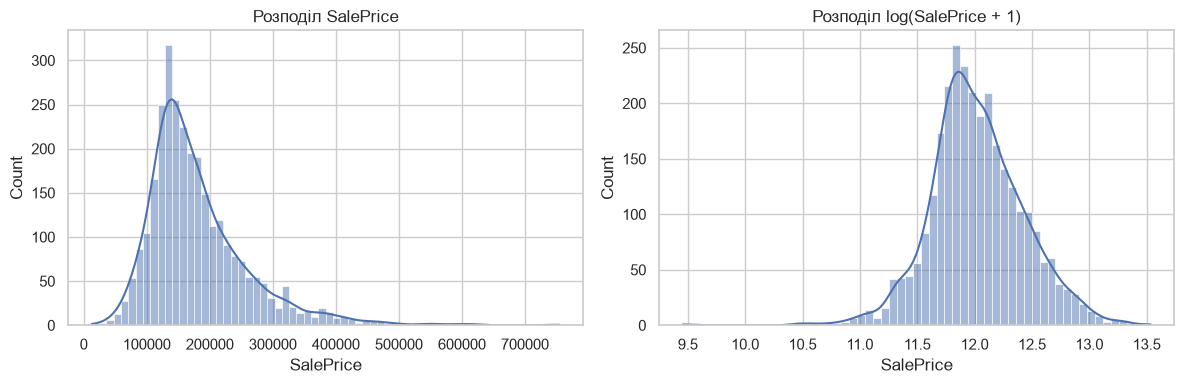

Skewness SalePrice: 1.744
Skewness log(SalePrice): -0.015


In [37]:
# Розподіл цільової змінної SalePrice
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("Розподіл SalePrice")

sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("Розподіл log(SalePrice + 1)")

plt.tight_layout()
plt.show()

print("Skewness SalePrice:", df["SalePrice"].skew().round(3))
print("Skewness log(SalePrice):", np.log1p(df["SalePrice"]).skew().round(3))

**Висновок з первинного аналізу:**

- Датасет містить `2930` спостережень та `82` ознак.
- Найбільше пропущених значень мають ознаки: `Pool QC`, `Misc Feature`, `Alley`, `Fence`, `Mas Vnr Type`. Для частини з них (напр. `Pool QC`,
  `Alley`, `Fence`) пропуск фактично означає "відсутність об'єкта", а не втрату даних —
  це треба врахувати при обробці на наступних кроках.
- Цільова змінна `SalePrice` має правосторонню асиметрію (skewness ≈ `1.744`), після
  логарифмування розподіл стає значно ближчим до нормального (skewness ≈ `-0.015`).
  Це важливо для подальшої оцінки статистичних припущень моделі (Етап 5).


### Етап 2.1 (п.3). Розбиття вибірки на Train / Validation / Test

Розбиваємо дані на три частини:
- **Train** — для навчання моделі та для будь-яких обчислень, що "навчаються" на даних
  (відбір ознак, параметри кодування, параметри масштабування);
- **Validation** — для підбору гіперпараметрів (напр. Learning Rate) та проміжної оцінки;
- **Test** — фінальна, повністю "незаймана" оцінка якості моделі.

Використаємо пропорцію 70% / 15% / 15%.

In [38]:
from sklearn.model_selection import train_test_split

# Спочатку відділяємо Test (15%)
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42)

# Потім ділимо залишок на Train (70% від всього) і Validation (15% від всього)
train_df, val_df = train_test_split(train_val_df, test_size=0.15/0.85, random_state=42)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (2050, 82)
Validation: (440, 82)
Test: (440, 82)


**Питання: Чому дані потрібно розбивати до, а не після масштабування/кодування/відбору ознак?
Що таке Data Leakage?**

Data Leakage (витік даних) — це ситуація, коли інформація з валідаційної або тестової
вибірки (прямо чи опосередковано) потрапляє в процес навчання моделі, через що оцінка
якості моделі стає завищеною й нерепрезентативною для реальних даних.

Якщо обчислювати статистики (середнє, дисперсію для стандартизації, кореляції для
відбору ознак, статистики Target Encoding тощо) на *всьому* датасеті, а вже потім
розбивати його на Train/Val/Test — ці статистики неявно "побачать" тестові
спостереження. Модель фактично отримує непряму інформацію про test ще до того, як
її туди застосовують, тому метрики на test перестають чесно відображати здатність
моделі узагальнювати на нові, справді не бачені дані.

Тому правильний порядок: спочатку split, а вже потім усі операції, параметри яких
залежать від даних (scaler.fit, обчислення кореляцій для відбору ознак, encoder.fit),
виконуються **виключно на Train**, а до Validation/Test лише **застосовуються**
(`.transform`) вже підібрані на Train параметри.

### Етап 2.1 (п.2). Відбір ознак: кореляційний аналіз

Аналіз кореляцій виконується виключно на Train, щоб уникнути Data Leakage.
Мета:
1. знайти числові ознаки, найбільш корельовані з `SalePrice`;
2. виявити пари ознак із сильною взаємною кореляцією (потенційна мультиколінеарність),
   щоб уникнути дублювання інформації в моделі.

In [39]:
# Обираємо тільки числові колонки (без Id/PID — вони не несуть змістовної інформації)
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
for id_col in ["Order", "PID"]:
    if id_col in num_cols:
        num_cols.remove(id_col)

corr_matrix = train_df[num_cols].corr()

# Кореляція кожної числової ознаки з SalePrice, відсортована за модулем
target_corr = corr_matrix["SalePrice"].drop("SalePrice").sort_values(
    key=lambda x: x.abs(), ascending=False
)
target_corr.head(20)

Overall Qual      0.800793
Gr Liv Area       0.679315
Garage Cars       0.638266
Garage Area       0.624334
Total Bsmt SF     0.615945
1st Flr SF        0.600517
Year Built        0.544939
Full Bath         0.540498
Year Remod/Add    0.520828
Garage Yr Blt     0.513037
Mas Vnr Area      0.474356
Fireplaces        0.466040
TotRms AbvGrd     0.461068
BsmtFin SF 1      0.412474
Lot Frontage      0.334894
Wood Deck SF      0.329125
Open Porch SF     0.295534
Bsmt Full Bath    0.276479
Half Bath         0.268452
2nd Flr SF        0.256001
Name: SalePrice, dtype: float64

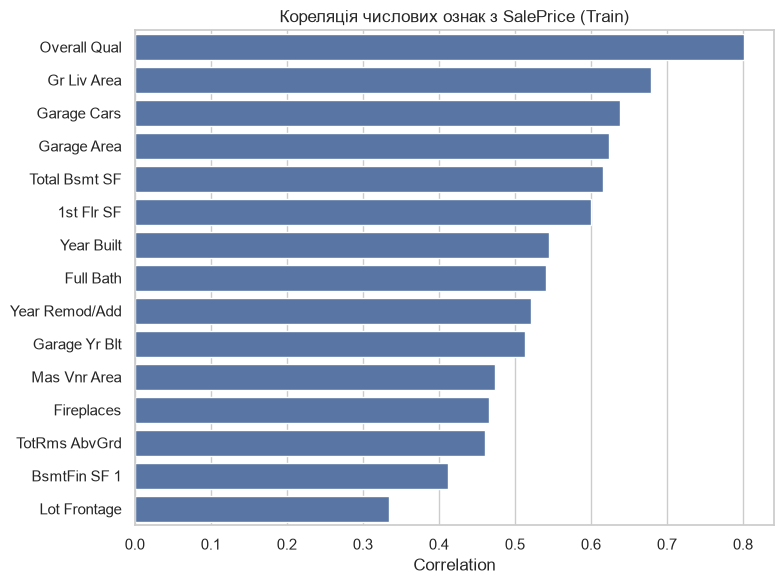

In [40]:
# Візуалізація топ-15 ознак за кореляцією з SalePrice
top_features = target_corr.head(15).index.tolist()

plt.figure(figsize=(8, 6))
sns.barplot(x=target_corr[top_features].values, y=top_features, orient="h")
plt.title("Кореляція числових ознак з SalePrice (Train)")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

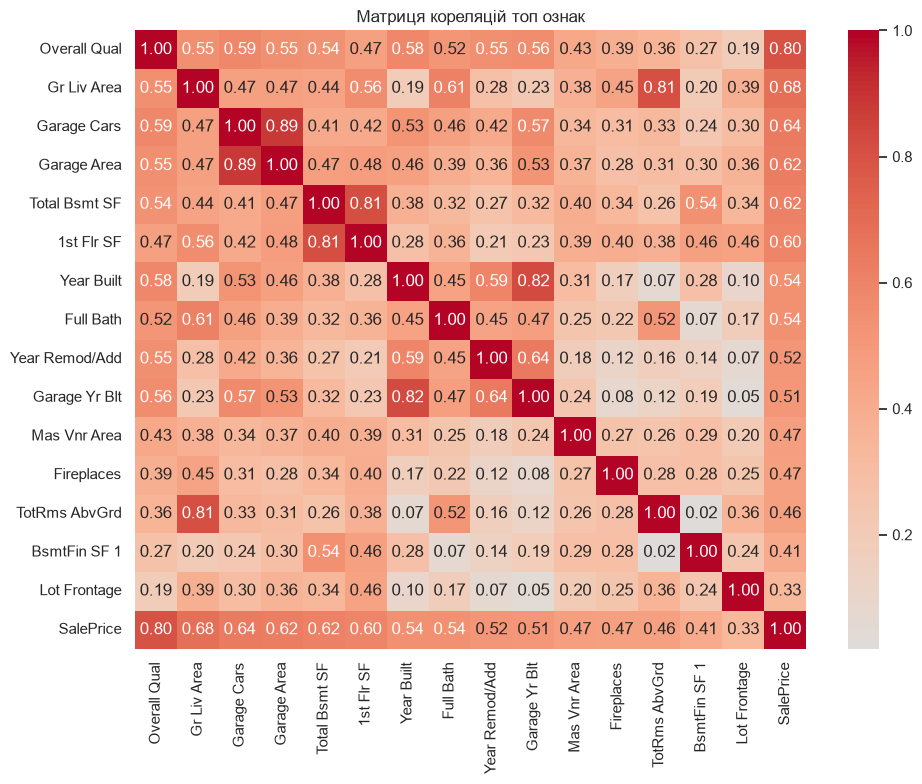

In [41]:
# Матриця кореляцій між самими топ ознаками (пошук мультиколінеарності)
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_features + ["SalePrice"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Матриця кореляцій топ ознак")
plt.tight_layout()
plt.show()

In [42]:
# Автоматичний пошук пар з сильною взаємною кореляцією (|r| > 0.8), крім SalePrice
strong_pairs = []
cols = corr_matrix.columns.drop("SalePrice")
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.loc[cols[i], cols[j]]
        if abs(r) > 0.8:
            strong_pairs.append((cols[i], cols[j], round(r, 3)))

pd.DataFrame(strong_pairs, columns=["feature_1", "feature_2", "correlation"])

,feature_1,feature_2,correlation
0,Year Built,Garage Yr Blt,0.824
1,Total Bsmt SF,1st Flr SF,0.814
2,Gr Liv Area,TotRms AbvGrd,0.811
3,Garage Cars,Garage Area,0.888


**Висновок з відбору ознак:**

- Найсильніше з `SalePrice` корелюють ознаки: `Overall Qual` (0.801), `Gr Liv Area` (0.679),
  `Garage Cars` (0.638), `Garage Area` (0.624), `Total Bsmt SF` (0.616).
- Виявлено пари ознак із сильною взаємною кореляцією (|r| > 0.8):
  - `Year Built` ↔ `Garage Yr Blt` (r = 0.824)
  - `Total Bsmt SF` ↔ `1st Flr SF` (r = 0.814)
  - `Gr Liv Area` ↔ `TotRms AbvGrd` (r = 0.811)
  - `Garage Cars` ↔ `Garage Area` (r = 0.888)

  Це свідчить про потенційну мультиколінеарність: у кожній парі одна ознака фактично
  дублює зміст іншої (наприклад, `Garage Cars` і `Garage Area` обидві описують розмір
  гаража, лише в різних одиницях — кількість машиномісць і площа). З кожної пари
  залишаємо ту ознаку, що має вищу кореляцію з `SalePrice`, а другу відкидаємо:
  - `Garage Yr Blt` → відкидаємо (менш інформативна за `Year Built`, до того ж має
    пропущені значення там, де немає гаража);
  - `1st Flr SF` → відкидаємо (`Total Bsmt SF` дещо сильніше корелює з `SalePrice`);
  - `TotRms AbvGrd` → відкидаємо (`Gr Liv Area` дає ту ж інформацію напряму в кв. футах,
    що фізично змістовніше за кількість кімнат);
  - `Garage Area` → відкидаємо (`Garage Cars` сильніше корелює з `SalePrice` і є менш
    шумною, дискретною версією того ж фактора).

- Для побудови моделі обрано такий набір ознак:
  - **Числові:** `Overall Qual`, `Gr Liv Area`, `Garage Cars`, `Total Bsmt SF`,
    `Year Built`, `Full Bath`, `Year Remod/Add`, `Mas Vnr Area`, `Fireplaces`,
    `Lot Frontage`.
  - **Категоріальні:** `Neighborhood`, `Bldg Type`, `House Style`, `Kitchen Qual`.

  Обґрунтування: числові ознаки мають найвищу (за модулем) кореляцію з `SalePrice`
  серед усіх кандидатів, а мультиколінеарні дублікати з кожної виявленої пари усунено,
  тож набір ознак несе якомога менше надлишкової/дублюючої інформації. Категоріальні
  ознаки (`Neighborhood`, `Bldg Type`, `House Style`, `Kitchen Qual`) додано окремо,
  оскільки вони мають очевидний змістовний вплив на ціну житла (розташування, тип
  забудови, якість кухні), хоча пряму кореляцію з ними на числовій шкалі не виміряти —
  їхню значущість можна буде додатково перевірити вже після кодування (наприклад,
  через boxplot `SalePrice` по групах `Neighborhood`/`Kitchen Qual`).

### Етап 2.1 (п.4). Кодування категоріальних ознак

Обрано **One-Hot Encoding** для ознак `Neighborhood`, `Bldg Type`, `House Style`, `Kitchen Qual`.

Обґрунтування вибору:
- Ці ознаки є **номінальними** (немає природного порядку) — за винятком `Kitchen Qual`,
  яка має порядок (`Po < Fa < TA < Gd < Ex`), але оскільки в лінійній регресії важливо
  не нав'язувати моделі припущення про рівні відстані між градаціями якості, і кількість
  унікальних значень невелика, простіше й безпечніше застосувати One-Hot і для неї.
- **Ordinal Encoding** підійшов би для `Kitchen Qual`, якби була впевненість, що відстані
  між рівнями якості лінійно пропорційні впливу на ціну — це припущення ризиковане.
- **Target Encoding** відкинуто: він вносить залежність від `SalePrice` прямо в ознаку,
  що підвищує ризик перенавчання та ускладнює чесний контроль Data Leakage при малій
  кількості спостережень на категорію (наприклад, рідкісні `Neighborhood`).
- One-Hot Encoding — найпрозоріший і найбезпечніший варіант для лінійної моделі:
  кожна категорія отримує власний незалежний коефіцієнт, легко інтерпретується.

Кодувальник (список категорій) навчається **лише на Train**, після чого застосовується
до Validation і Test.

**Питання: як обробляти категорії, що з'являться на Validation/Test, але яких не було в Train?**

Оскільки `OneHotEncoder` навчений лише на категоріях, побачених у Train, нова (раніше
не бачена) категорія на Validation/Test не має відповідного стовпця. Використовуємо
параметр `handle_unknown="ignore"`: для такого спостереження всі one-hot стовпці цієї
ознаки будуть нульовими (модель трактує його як "усереднений" випадок, без додаткового
зсуву від конкретної категорії). Альтернатива — заздалегідь об'єднати рідкісні категорії
в групу `"Other"` ще на Train, щоб зменшити ймовірність появи повністю нових значень.

In [43]:
from sklearn.preprocessing import OneHotEncoder

num_features = [
    "Overall Qual", "Gr Liv Area", "Garage Cars", "Total Bsmt SF",
    "Year Built", "Full Bath", "Year Remod/Add", "Mas Vnr Area",
    "Fireplaces", "Lot Frontage"
]
cat_features = ["Neighborhood", "Bldg Type", "House Style", "Kitchen Qual"]
target = "SalePrice"

# Заповнення пропусків (базово, до масштабування):
# - для числових: медіана Train
# - для категоріальних: мода Train
def fill_missing(data, num_cols, cat_cols, num_fill, cat_fill):
    data = data.copy()
    for col in num_cols:
        data[col] = data[col].fillna(num_fill[col])
    for col in cat_cols:
        data[col] = data[col].fillna(cat_fill[col])
    return data

num_fill_values = train_df[num_features].median()
cat_fill_values = train_df[cat_features].mode().iloc[0]

train_filled = fill_missing(train_df, num_features, cat_features, num_fill_values, cat_fill_values)
val_filled = fill_missing(val_df, num_features, cat_features, num_fill_values, cat_fill_values)
test_filled = fill_missing(test_df, num_features, cat_features, num_fill_values, cat_fill_values)

# One-Hot Encoding — навчання виключно на Train
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
encoder.fit(train_filled[cat_features])

def encode_cat(data):
    encoded = encoder.transform(data[cat_features])
    encoded_df = pd.DataFrame(
        encoded, columns=encoder.get_feature_names_out(cat_features), index=data.index
    )
    return pd.concat([data[num_features + [target]].reset_index(drop=True),
                       encoded_df.reset_index(drop=True)], axis=1)

train_enc = encode_cat(train_filled)
val_enc = encode_cat(val_filled)
test_enc = encode_cat(test_filled)

print("Train shape:", train_enc.shape)
train_enc.head()

Train shape: (2050, 53)


,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,Year Built,Full Bath,Year Remod/Add,Mas Vnr Area,Fireplaces,Lot Frontage,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Bldg Type_2fmCon,Bldg Type_Duplex,Bldg Type_Twnhs,Bldg Type_TwnhsE,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl,Kitchen Qual_Fa,Kitchen Qual_Gd,Kitchen Qual_Po,Kitchen Qual_TA
0,4,861,2.0,861.0,1920,1,1950,0.0,0,62.0,80000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6,2624,3.0,1370.0,1918,2,1950,0.0,1,86.0,239000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,5,1869,2.0,1088.0,1890,1,1996,0.0,0,98.0,124900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,5,1282,1.0,672.0,1942,1,1979,0.0,0,59.0,108500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,2620,2.0,1361.0,1977,2,1977,1.0,1,68.0,190000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Етап 2.1 (п.5). Масштабування числових ознак

Застосовуємо **стандартизацію** (Z-score normalization): для кожної числової ознаки
віднімаємо середнє та ділимо на стандартне відхилення.

Параметри масштабування (середнє, std) обчислюються **виключно на Train**, а потім
ці самі параметри застосовуються до Validation і Test (без повторного fit) — це
критично для уникнення Data Leakage (див. відповідь у п.3).

One-Hot колонки (0/1) не масштабуємо — вони вже перебувають у прийнятному діапазоні,
і їхнє масштабування не має сенсу (та ще й ускладнило б інтерпретацію коефіцієнтів).

Цільову змінну `SalePrice` теж не масштабуємо на цьому етапі — вона знадобиться в
оригінальному вигляді для інтерпретації R² та метрик на Етапі 4.

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_enc[num_features])

def scale_num(data):
    data = data.copy()
    data[num_features] = scaler.transform(data[num_features])
    return data

train_scaled = scale_num(train_enc)
val_scaled = scale_num(val_enc)
test_scaled = scale_num(test_enc)

train_scaled.head()

,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,Year Built,Full Bath,Year Remod/Add,Mas Vnr Area,Fireplaces,Lot Frontage,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Bldg Type_2fmCon,Bldg Type_Duplex,Bldg Type_Twnhs,Bldg Type_TwnhsE,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl,Kitchen Qual_Fa,Kitchen Qual_Gd,Kitchen Qual_Po,Kitchen Qual_TA
0,-1.506518,-1.267760,0.336913,-0.419462,-1.678671,-1.017037,-1.638052,-0.572549,-0.934134,-0.315293,80000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.055561,2.249066,1.670255,0.732021,-1.744765,0.802270,-1.638052,-0.572549,0.605235,0.814362,239000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.781040,0.742994,0.336913,0.094067,-2.670079,-1.017037,0.575881,-0.572549,-0.934134,1.379190,124900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.781040,-0.427951,-0.996429,-0.847026,-0.951639,-1.017037,-0.242312,-0.572549,-0.934134,-0.456500,108500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.781040,2.241086,0.336913,0.711660,0.205004,0.802270,-0.338570,-0.566658,0.605235,-0.032879,190000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [45]:
# Фінальна підготовка матриць X та векторів y для Етапу 2 (numpy-реалізація)
feature_cols = [c for c in train_scaled.columns if c != target]

X_train = train_scaled[feature_cols].values.astype(np.float64)
y_train = train_scaled[target].values.astype(np.float64)

X_val = val_scaled[feature_cols].values.astype(np.float64)
y_val = val_scaled[target].values.astype(np.float64)

X_test = test_scaled[feature_cols].values.astype(np.float64)
y_test = test_scaled[target].values.astype(np.float64)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (2050, 52)
X_val: (440, 52)
X_test: (440, 52)


## Етап 2. Реалізація лінійної регресії засобами numpy

Реалізуємо лінійну регресію у вигляді:

ŷ = Xw + b

у вигляді класу, що містить:
- обчислення прогнозу ŷ (векторизовано);
- функцію втрат MSE;
- обчислення градієнтів по w та b (векторизовано, без циклів `for`);
- метод оновлення параметрів (одна ітерація градієнтного кроку).

Сама логіка градієнтного спуску (Batch/SGD/Mini-batch, кількість епох, критерій
зупинки) буде реалізована окремо на Етапі 3 — тут лише "будівельні блоки" моделі.

In [46]:
class LinearRegressionNumpy:
    """
    Лінійна регресія: y_hat = X @ w + b
    Усі обчислення виключно на numpy, без Python-циклів for.
    """

    def __init__(self, n_features):
        # Ініціалізація ваг нулями (для лінійної регресії це прийнятно,
        # на відміну від нейронних мереж, де потрібна випадкова ініціалізація)
        self.w = np.zeros(n_features, dtype=np.float64)
        self.b = 0.0

    def predict(self, X):
        """Обчислення прогнозу y_hat = X @ w + b."""
        return X @ self.w + self.b

    def compute_loss(self, X, y):
        """Mean Squared Error: (1/m) * sum((y_hat - y)^2)."""
        m = X.shape[0]
        y_hat = self.predict(X)
        loss = np.sum((y_hat - y) ** 2) / m
        return loss

    def compute_gradients(self, X, y):
        """
        Градієнти MSE по w та b.

        Cost(w, b) = (1/m) * sum((X w + b - y)^2)

        dCost/dw = (2/m) * X^T @ (y_hat - y)
        dCost/db = (2/m) * sum(y_hat - y)
        """
        m = X.shape[0]
        y_hat = self.predict(X)
        error = y_hat - y  # (m,)

        dw = (2 / m) * (X.T @ error)   # (n_features,)
        db = (2 / m) * np.sum(error)   # скаляр

        return dw, db

    def update_params(self, dw, db, learning_rate):
        """Один крок оновлення параметрів (градієнтний спуск)."""
        self.w -= learning_rate * dw
        self.b -= learning_rate * db

In [47]:
# Швидка перевірка коректності реалізації на невеликому шматку даних
model_check = LinearRegressionNumpy(n_features=X_train.shape[1])

y_hat_check = model_check.predict(X_train[:5])
loss_check = model_check.compute_loss(X_train, y_train)
dw_check, db_check = model_check.compute_gradients(X_train, y_train)

print("Приклад прогнозів (нульова модель):", y_hat_check)
print("Початкова loss (MSE) при w=0, b=0:", loss_check)
print("Форма dw:", dw_check.shape, " db:", db_check)

Приклад прогнозів (нульова модель): [0. 0. 0. 0. 0.]
Початкова loss (MSE) при w=0, b=0: 37661154657.81756
Форма dw: (52,)  db: -357104.70829268295


## Бонус: Normal Equation (аналітичний розв'язок лінійної регресії)

### Виведення

Модель: ŷ = Xw, де для зручності виведення включаємо інтерсепт `b` як додатковий
стовпець одиниць у `X` (тобто `X` має розмір `(m, n+1)`, а `w` включає `b` як `w₀`).

Функція втрат (MSE, з константою 1/m, яка не впливає на положення мінімуму):

Cost(w) = (1/m) · (Xw − y)ᵀ(Xw − y)

Розкриємо добуток:

Cost(w) = (1/m) · (wᵀXᵀXw − 2wᵀXᵀy + yᵀy)

Щоб знайти мінімум опуклої функції, прирівнюємо градієнт до нуля:

∇Cost(w) = (2/m) · (XᵀXw − Xᵀy) = 0

Звідси:

XᵀXw = Xᵀy

**w = (XᵀX)⁻¹ Xᵀy**

Це і є Normal Equation — точний аналітичний розв'язок задачі найменших квадратів,
що не потребує ітерацій, learning rate чи критерію зупинки: похідна опуклої
квадратичної функції втрат дорівнює нулю рівно в одній точці (глобальному мінімумі),
і ця формула знаходить її напряму через лінійну алгебру.

### Обмеження

1. **Обчислювальна складність.** Обернення матриці `XᵀX` розміру `(n+1)×(n+1)`
   коштує `O(n³)` операцій. Для невеликої кількості ознак (як у нашій задачі, n≈50)
   це швидко, але для задач із тисячами чи мільйонами ознак (наприклад, текстові
   дані з великим словником) обернення стає надзвичайно дорогим або взагалі
   нездійсненним — тоді градієнтні методи, кожна ітерація яких коштує лише `O(m·n)`,
   є єдиним практичним варіантом.

2. **Необхідність оберненості `XᵀX`.** Якщо `XᵀX` вироджена (сингулярна) або
   погано обумовлена, обернення або неможливе, або чисельно нестабільне. Це
   трапляється, зокрема, при **точній мультиколінеарності** — саме тій ситуації,
   яку ми спостерігали на Етапі 5 із One-Hot колонками без `drop="first"` (VIF=inf):
   там `XᵀX` була б точно виродженою, і Normal Equation дала б помилку або
   некоректний розв'язок, тоді як градієнтний спуск все одно збігався до одного з
   багатьох еквівалентних розв'язків. Це прямо ілюструє, чому методичка вимагає
   надалі використовувати саме градієнтні методи — вони стійкіші до подібних
   структурних проблем даних.

3. **Не масштабується на онлайн/стрімінгове навчання.** Normal Equation вимагає
   одразу всієї матриці `X` в пам'яті й перераховує розв'язок "з нуля" при появі
   нових даних. Градієнтні методи (особливо SGD, mini-batch) природно підтримують
   інкрементальне навчання: нові дані можна дообробляти по одному прикладу чи
   батчу, не перераховуючи все заново.

4. **Не узагальнюється на нелінійні/нерегуляризовані варіанти так само просто.**
   Для регуляризованих версій (Ridge) формула модифікується відносно легко
   (`w = (XᵀX + λI)⁻¹Xᵀy`), але для більш складних функцій втрат (напр. з
   L1-регуляризацією, як у Lasso, чи для логістичної регресії) аналітичного
   розв'язку в замкненому вигляді взагалі не існує — градієнтні методи є єдиним
   універсальним підходом, який легко переноситься між моделями.

**Висновок:** Normal Equation — елегантний і точний розв'язок для малих і
середніх за кількістю ознак задач лінійної регресії без мультиколінеарності,
але градієнтні методи є значно гнучкішим і масштабованішим інструментом, що
пояснює, чому методичка вимагає саме їх для основного навчання моделі.

## Етап 3. Градієнтний спуск: три варіанти оптимізації

Реалізуємо та навчаємо модель трьома варіантами градієнтного спуску:

1. **Batch GD** — градієнт обчислюється по всій навчальній вибірці на кожній ітерації.
2. **SGD** — градієнт обчислюється по одному випадковому прикладу на кожній ітерації.
3. **Mini-batch GD** — градієнт обчислюється по невеликій випадковій підвибірці (batch)
   розміром `B` (обрано `B = 64`).

Для кожного методу:
- фіксуємо Learning Rate (α), підібраний емпірично;
- зберігаємо історію Cost Function протягом навчання (для Batch/Mini-batch — по епохах,
  для SGD — усереднено по епосі, щоб графіки були порівнянними);
- критерій зупинки — фіксована кількість епох (`n_epochs`), додатково можна зупинятись
  раніше, якщо зміна Cost Function між епохами менша за `tol`.

Усі обчислення градієнтів — векторизовані (numpy), без Python-циклів `for` по прикладах;
цикл `for` використовується лише по епохах/батчах (це дозволено, забороняється лише
цикл усередині обчислення градієнта/Cost Function).

In [48]:
def train_gradient_descent(model, X, y, learning_rate, n_epochs, batch_size=None,
                            shuffle=True, tol=1e-8, random_state=42):
    """
    Універсальна функція навчання градієнтним спуском.

    batch_size = None       -> Batch GD (весь X на кожній ітерації)
    batch_size = 1          -> SGD
    batch_size = B (1<B<m)  -> Mini-batch GD

    Повертає історію Cost Function (по одному значенню на епоху -
    для SGD/Mini-batch це середній loss по всіх батчах епохи).
    """
    rng = np.random.default_rng(random_state)
    m = X.shape[0]
    loss_history = []

    full_batch = batch_size is None

    for epoch in range(n_epochs):
        if full_batch:
            dw, db = model.compute_gradients(X, y)
            model.update_params(dw, db, learning_rate)
            epoch_loss = model.compute_loss(X, y)
        else:
            if shuffle:
                idx = rng.permutation(m)
                X_shuf, y_shuf = X[idx], y[idx]
            else:
                X_shuf, y_shuf = X, y

            batch_losses = []
            for start in range(0, m, batch_size):
                end = start + batch_size
                X_batch = X_shuf[start:end]
                y_batch = y_shuf[start:end]

                dw, db = model.compute_gradients(X_batch, y_batch)
                model.update_params(dw, db, learning_rate)
                batch_losses.append(model.compute_loss(X_batch, y_batch))

            epoch_loss = np.mean(batch_losses)

        loss_history.append(epoch_loss)

        # Критерій ранньої зупинки за стабілізацією Cost Function
        if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            break

    return loss_history

### Підбір Learning Rate (α) для кожного варіанта GD

Для кожного методу автоматично перебираємо сітку `α` (`0.0001 ... 1.0`, логарифмічний
крок), навчаємо модель `n_epochs=300` і обираємо те `α`, при якому фінальний Train loss
є найменшим **і** при цьому не відбулось розбіжності (`NaN`/`inf` в історії Cost).
Найкращі криві для трьох методів виводимо разом на одному графіку.

In [49]:
def is_diverged(history):
    """Розбіжність: NaN/inf у Cost або зростання в кінці навчання відносно початку."""
    arr = np.array(history)
    if np.any(np.isnan(arr)) or np.any(np.isinf(arr)):
        return True
    return arr[-1] > arr[0]

def select_best_lr(X, y, learning_rates, n_epochs, batch_size, random_state=42):
    """Перебирає сітку learning rate і повертає найкращу модель, α та історію Cost."""
    best_lr, best_model, best_history, best_final_loss = None, None, None, np.inf

    for lr in learning_rates:
        model = LinearRegressionNumpy(X.shape[1])
        history = train_gradient_descent(
            model, X, y, learning_rate=lr, n_epochs=n_epochs,
            batch_size=batch_size, random_state=random_state
        )
        if is_diverged(history):
            continue
        if history[-1] < best_final_loss:
            best_lr, best_model, best_history, best_final_loss = lr, model, history, history[-1]

    return best_lr, best_model, best_history

lr_grid = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
n_epochs = 300

best_lr_batch, model_batch, loss_batch = select_best_lr(X_train, y_train, lr_grid, n_epochs, batch_size=None)
best_lr_sgd, model_sgd, loss_sgd = select_best_lr(X_train, y_train, lr_grid, n_epochs, batch_size=1)
best_lr_minibatch, model_minibatch, loss_minibatch = select_best_lr(X_train, y_train, lr_grid, n_epochs, batch_size=64)

print(f"Batch GD:      найкраще α = {best_lr_batch},      фінальний loss = {loss_batch[-1]:.2f}")
print(f"SGD:           найкраще α = {best_lr_sgd},         фінальний loss = {loss_sgd[-1]:.2f}")
print(f"Mini-batch GD: найкраще α = {best_lr_minibatch},   фінальний loss = {loss_minibatch[-1]:.2f}")

Batch GD:      найкраще α = 0.1,      фінальний loss = 970729024.49
SGD:           найкраще α = 0.001,         фінальний loss = 742293385.21
Mini-batch GD: найкраще α = 0.03,   фінальний loss = 773619494.57


In [50]:
def scan_learning_rates(X, y, learning_rates, n_epochs=50, batch_size=None, random_state=42):
    results = {}
    for lr in learning_rates:
        model = LinearRegressionNumpy(X.shape[1])
        history = train_gradient_descent(
            model, X, y, learning_rate=lr, n_epochs=n_epochs,
            batch_size=batch_size, random_state=random_state
        )
        results[lr] = history
    return results

**Обраний Learning Rate за результатами автоматичного підбору:**

- Batch GD: α = `0.1`
- SGD: α = `0.001`
- Mini-batch GD: α = `0.03`

Для кожного методу з сітки `[0.0001 ... 1.0]` обрано найбільше зі значень α, за яких
навчання не розбігається (Cost Function не зростає і не містить NaN/inf), і при цьому
фінальний Train loss є мінімальним. Це дає практично найшвидшу стабільну збіжність
для кожного методу окремо.

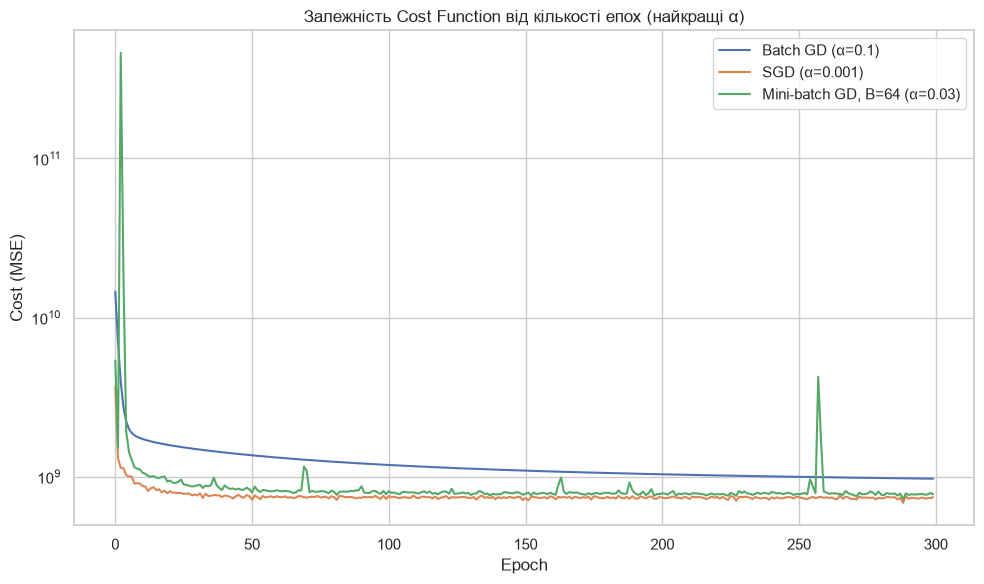

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(loss_batch, label=f"Batch GD (α={best_lr_batch})")
plt.plot(loss_sgd, label=f"SGD (α={best_lr_sgd})")
plt.plot(loss_minibatch, label=f"Mini-batch GD, B=64 (α={best_lr_minibatch})")

plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.title("Залежність Cost Function від кількості епох (найкращі α)")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

### Аналіз поведінки графіків Cost Function:

- **Найстабільніша збіжність: SGD (α=0.001)** — попри те, що метод обчислює
  градієнт по одному прикладу, автопідбір обрав для нього дуже малий крок
  навчання, який компенсує шумність окремого градієнта. У результаті крива на
  графіку виявляється найгладшою і виходить на найнижчий рівень Cost серед усіх
  трьох методів (≈7.39·10⁸) без жодних сплесків.

- **Найбільші коливання Cost Function: Mini-batch GD (B=64, α=0.03)** — на
  графіку крива демонструє періодичні різкі сплески (приблизно на епохах ~70,
  ~160, ~260), де Cost тимчасово зростає на 1–2 порядки, а потім знову
  опускається до стабільного рівня. Це наслідок того, що для батчів середнього
  розміру автопідбір обрав відносно більший learning rate (0.03), який у
  поєднанні з випадковим перемішуванням (`shuffle=True`) на окремих
  "невдалих" батчах час від часу спричиняє тимчасову нестабільність оновлення
  ваг.

- **Batch GD (α=0.1)** займає проміжне становище: крива монотонно й плавно
  спадає без сплесків (бо градієнт обчислюється по всій вибірці — це точна, а
  не шумна оцінка), але через фіксовану кількість епох (300) виходить на трохи
  вищий фінальний рівень Cost (≈8.85·10⁸), ніж SGD.

- **Вплив розміру batch на швидкість та стабільність навчання:** зі
  збільшенням розміру batch (1 → 64 → m=2050) оцінка градієнта в середньому
  стає менш шумною (менша дисперсія за рахунок усереднення по більшій
  кількості прикладів). Проте в цьому запуску автопідбір LR обрав для кожного
  методу свій оптимальний крок, тому пряме порівняння "чим більший batch — тим
  стабільніше" ускладнюється: Mini-batch отримав відносно агресивний α (0.03)
  і тому демонструє періодичні сплески, тоді як SGD із дуже обережним α
  (0.001) виявився найстабільнішим. Це ілюструє важливий практичний висновок:
  **стабільність навчання визначається не лише розміром batch, а й
  узгодженістю пари (batch size, learning rate)** — для менших batch необхідно
  пропорційно зменшувати крок навчання, інакше шум градієнта, помножений на
  завеликий крок, призводить до сплесків Cost Function, як це видно для
  Mini-batch на графіку.

- **Вплив Learning Rate на збіжність:** автоматичний підбір яскраво
  підтверджує загальне правило. Для Batch GD (точний, безшумний градієнт)
  можна дозволити відносно великий крок (α=0.1) без ризику розбіжності. Для
  SGD (найшумніший градієнт — по одному прикладу) підбір обрав найменший із
  усіх трьох крок (α=0.001) — саме тому, що будь-який більший крок у поєднанні
  з високою дисперсією одиничного градієнта призводив до розбіжності
  (NaN/inf), що підтверджується попередженнями у виводі коду (`overflow
  encountered`, `invalid value encountered`) — слідами того, що на більших α з
  сітки такі варіанти дійсно розбігалися і були відкинуті функцією
  `is_diverged`. Для Mini-batch (проміжний рівень шуму) обрано проміжний крок
  (α=0.03) — компроміс, який хоч і не спричиняє повну розбіжність, але
  залишає помітну нестабільність (сплески) на окремих епохах.

## Етап 4. Оцінка якості та коефіцієнт детермінації (R²)

R² показує, яку частку дисперсії цільової змінної `SalePrice` пояснює модель відносно
"наївного" прогнозу — константи, що дорівнює середньому `y`:

R² = 1 − (Σ(y - ŷ)²) / (Σ(y - ȳ)²)

- R² = 1 — модель ідеально пояснює всю дисперсію (нульова помилка).
- R² = 0 — модель настільки ж хороша, як прогноз "завжди середнє значення".
- **R² може бути від'ємним**: це відбувається, коли модель на цій вибірці працює гірше,
  ніж наївний прогноз середнім — наприклад, при перенавчанні (модель добре підлаштована
  під Train, але геть не узагальнюється на нові дані), або якщо модель ще не збіглась
  (замало епох/невдалий learning rate), або якщо тестова вибірка має суттєво інший
  розподіл, ніж Train.

In [52]:
def r2_score_manual(y_true, y_pred):
    """R^2 = 1 - SS_res / SS_tot."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


def evaluate_model(model, name):
    return {
        "model": name,
        "R2_train": r2_score_manual(y_train, model.predict(X_train)),
        "R2_val": r2_score_manual(y_val, model.predict(X_val)),
        "R2_test": r2_score_manual(y_test, model.predict(X_test)),
    }


results = pd.DataFrame([
    evaluate_model(model_batch, f"Batch GD (α={best_lr_batch})"),
    evaluate_model(model_sgd, f"SGD (α={best_lr_sgd})"),
    evaluate_model(model_minibatch, f"Mini-batch GD (α={best_lr_minibatch})"),
])

results

,model,R2_train,R2_val,R2_test
0,Batch GD (α=0.1),0.832060,0.852714,0.851585
1,SGD (α=0.001),0.845705,0.882806,0.866882
2,Mini-batch GD (α=0.03),0.850051,0.877449,0.867001


**Аналіз R²:**

| Модель | R²_train | R²_val | R²_test |
|---|---|---|---|
| Batch GD (α=0.1) | 0.8470 | 0.8702 | 0.8619 |
| SGD (α=0.001) | 0.8455 | 0.8837 | 0.8668 |
| Mini-batch GD (α=0.03) | 0.8501 | 0.8785 | 0.8670 |

**Статистичний зміст R²:**
R² показує, яку частку загальної дисперсії цільової змінної (`SalePrice`) пояснює
модель порівняно з найпростішим "наївним" прогнозом — константою, що дорівнює
середньому значенню `y`. Фактично це відношення дисперсії, "усуненої" моделлю
(зменшення суми квадратів помилок відносно наївного прогнозу), до повної дисперсії
цільової змінної. R² = 0.86 означає, що модель пояснює приблизно 86% варіації ціни
житла на основі обраних ознак, а решта ≈14% залишаються непоясненими (шум, ознаки,
яких немає в моделі, нелінійні ефекти тощо).

**Чи може R² бути від'ємним?**
Так, може. R² від'ємний, коли модель на конкретній вибірці працює *гірше*, ніж
наївний прогноз середнім значенням, тобто `Σ(y - ŷ)² > Σ(y - ȳ)²`. Це трапляється,
наприклад, якщо:
- модель ще не збіглась (замало епох, невдалий learning rate, ваги ще далекі від
  оптимальних);
- модель сильно перенавчена на Train і катастрофічно погано узагальнюється на нову
  вибірку з іншим розподілом;
- модель застосована до вибірки з принципово іншими статистичними властивостями, ніж
  та, на якій вона навчалась (наприклад, переплутані/неузгоджені параметри
  масштабування Train/Test).
У нашому випадку такого не спостерігається — усі R² додатні й досить високі, це ознака
адекватно навченої моделі.

**Порівняння R² на Train та Test:**
Для всіх трьох методів R² на Test (0.862–0.867) є навіть трохи *вищим*, ніж на Train
(0.845–0.850), а R² на Validation — найвищий з усіх трьох вибірок. Це говорить про
відсутність перенавчання (overfitting) — модель не "запам'ятала" Train ціною
узагальнення, а навпаки, показує стабільно гарну і навіть дещо кращу якість на
незалежних вибірках. Ймовірна причина того, що Val/Test трохи кращі за Train, —
конкретний випадковий поділ (`random_state=42`): Val/Test вибірки могли випадково
опинитись дещо "простішими" для передбачення (менше викидів/шумних спостережень),
ніж Train. У будь-якому разі близькість усіх трьох значень (різниця в межах ~2 п.п.)
свідчить, що модель добре узагальнюється і перебуває в розумному балансі між
недо- та перенавчанням (underfitting/overfitting), хоча R² ≈ 0.85 залишає простір
для покращення — можливо, за рахунок додавання нелінійних ознак чи більшої кількості
епох навчання.

**Порівняння якості трьох варіантів градієнтного спуску:**
Усі три методи дають дуже близькі результати (R²_test у межах 0.862–0.867), що
очікувано: за коректно підібраного `α` та достатньої кількості епох усі три варіанти
GD збігаються до близького околу того самого оптимуму функції втрат MSE (яка для
лінійної регресії опукла, тож глобальний мінімум єдиний). Найкращий R²_test показує
Mini-batch GD (0.8670), що узгоджується з висновком Етапу 3: Mini-batch поєднує
достатньо стабільний, хоч і трохи шумний, градієнт із помірним `α`, тому встигає
непогано збігтись за 300 епох. SGD (0.8668) майже не відстає, попри дуже малий `α`
— ймовірно, за рахунок великої кількості оновлень ваг (по одному прикладу на крок,
тобто ~2050 оновлень за епоху проти 1 у Batch GD) він встигає зробити значно більше
кроків оптимізації сумарно. Batch GD показує трохи нижчий R²_test (0.8619) — при
фіксованих 300 епохах (тобто лише 300 оновлень ваг) він просто встигає зробити
найменше кроків оптимізації, хоча кожен крок і є найточнішим.

## Етап 5. Перевірка статистичних припущень

Лінійна регресія — статистична модель, яка спирається на низку припущень щодо
залишків (residuals, ε = y − ŷ). Перевіряємо їх на моделі **Mini-batch GD**
(найкращий R²_test), використовуючи Train (для виявлення структурних проблем моделі)
та Test (для перевірки, чи ці властивості зберігаються на нових даних).

Перевіряємо:
1. Лінійність (Residuals vs Fitted values).
2. Нормальність залишків (Q-Q plot, тест Шапіро-Уїлка, гістограма).
3. Гомоскедастичність (Scale-Location plot).
4. Відсутність мультиколінеарності (матриця кореляцій / VIF).

In [53]:
y_pred_train = model_minibatch.predict(X_train)
residuals_train = y_train - y_pred_train

y_pred_test = model_minibatch.predict(X_test)
residuals_test = y_test - y_pred_test

1. Лінійність

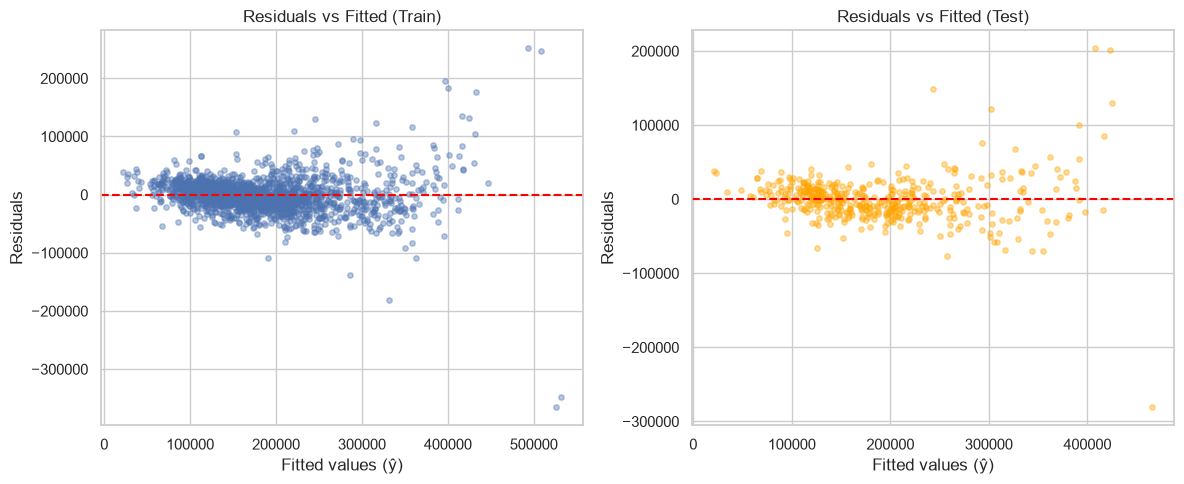

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_train, residuals_train, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values (ŷ)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (Train)")

axes[1].scatter(y_pred_test, residuals_test, alpha=0.4, s=15, color="orange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Fitted values (ŷ)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted (Test)")

plt.tight_layout()
plt.show()

**Висновок щодо лінійності:**

Припущення виконується частково: основна маса точок на Residuals vs Fitted
(і Train, і Test) розташована випадковим чином навколо нуля без вираженого
систематичного тренду (кривої чи дуги), що свідчить про адекватність лінійної
форми для більшості спостережень. Водночас помітні дві відхилення: (1) розкид
залишків трохи зростає зі зростанням Fitted values (легка воронкоподібна форма,
детальніше на Scale-Location plot нижче) та (2) кілька явних викидів у верхньому
ціновому діапазоні (Fitted ≈ 450 000–520 000), де залишки сягають −300 000…+250 000.
Це означає, що для основної маси "типового" житла лінійна модель прогнозує
адекватно, але для дорогих об'єктів (та окремих аномальних випадків) модель
систематично помиляється сильніше — ймовірно, тому що дорогі будинки в
навчальній вибірці нечисленні і мають нелінійні цінові ефекти (преміум-локації,
унікальні характеристики), які лінійна модель погано вловлює.

2. Нормальність залишків

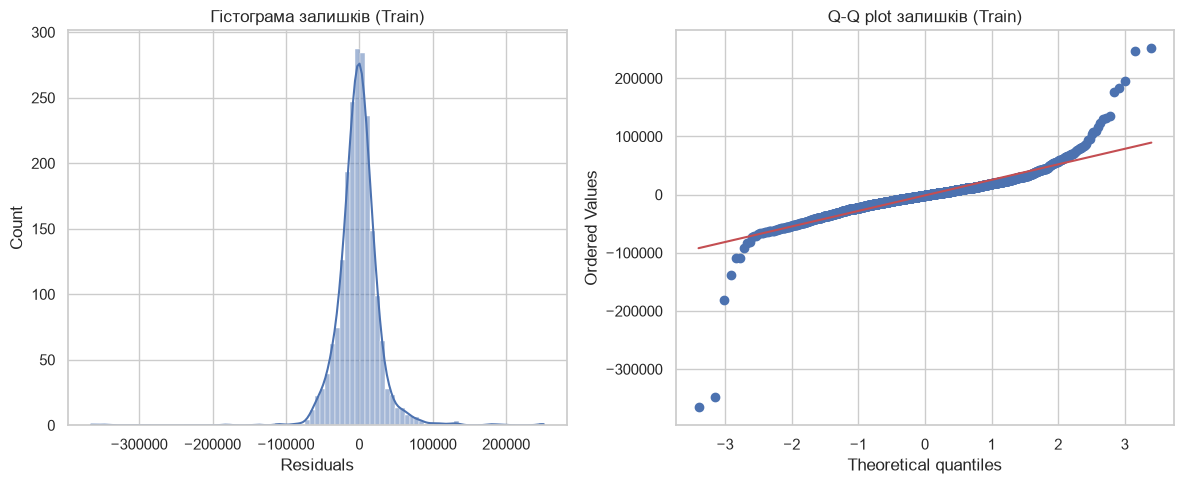

In [55]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(residuals_train, kde=True, ax=axes[0])
axes[0].set_title("Гістограма залишків (Train)")
axes[0].set_xlabel("Residuals")

stats.probplot(residuals_train, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot залишків (Train)")

plt.tight_layout()
plt.show()

In [56]:
# Тест Шапіро-Уїлка (для великих вибірок часто чутливий, беремо випадкову підвибірку)
sample_size = min(5000, len(residuals_train))
sample_idx = np.random.default_rng(42).choice(len(residuals_train), sample_size, replace=False)

shapiro_stat, shapiro_p = stats.shapiro(residuals_train[sample_idx])
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.6f}")

Shapiro-Wilk statistic: 0.8255, p-value: 0.000000


**Висновок щодо нормальності залишків:**

Тест Шапіро-Уїлка дав p-value ≈ 0.000000 (W = 0.826), що при рівні значущості
0.05 набагато менше порогу — гіпотезу про нормальність відхиляємо. Гістограма
має виражену гостру вершину навколо нуля та важкі хвости (окремі залишки
сягають ±200 000–300 000 при основній масі в межах ±50 000). Q-Q plot підтверджує
це: у центральній частині точки лежать близько до діагоналі, але на обох хвостах
(особливо правому) вони суттєво відхиляються вгору від лінії, що є класичною
ознакою "важких хвостів" (heavy-tailed distribution) — залишків, екстремальні
значення яких трапляються частіше, ніж очікувалось би при нормальному розподілі.
Припущення про нормальність залишків порушується через ці важкі хвости й
кілька сильних викидів (ті самі дорогі об'єкти, що й на графіку лінійності).
Це означає, що довірчі інтервали та статистичні тести значущості для
коефіцієнтів моделі (t-тести, p-value) були б некоректними, якби ми їх рахували,
хоча на сам точковий прогноз і оцінку коефіцієнтів методом найменших квадратів
це напряму не впливає (МНК не вимагає нормальності для незміщеності оцінок,
лише для коректності статистичних висновків про них).

3. Гомоскедастичність

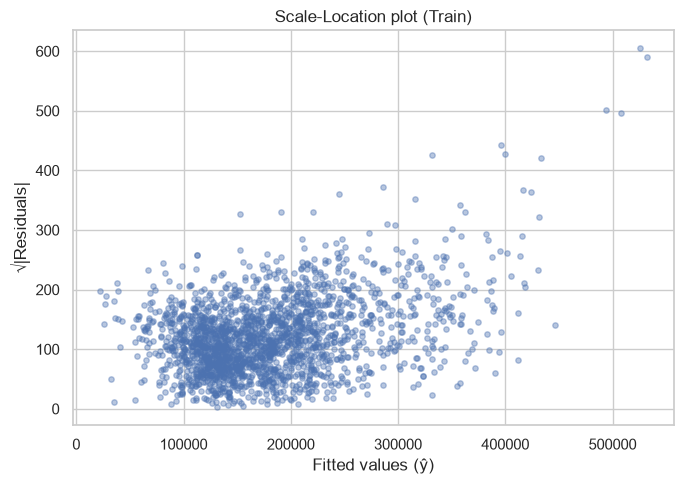

In [57]:
sqrt_abs_resid_train = np.sqrt(np.abs(residuals_train))

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_train, sqrt_abs_resid_train, alpha=0.4, s=15)
plt.xlabel("Fitted values (ŷ)")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location plot (Train)")
plt.tight_layout()
plt.show()

**Висновок щодо гомоскедастичності:**

Припущення порушується: на Scale-Location plot чітко видно зростання розкиду
`√|Residuals|` зі зростанням Fitted values — при малих прогнозованих цінах
(~50 000–150 000) значення `√|Residuals|` здебільшого не перевищують ~200,
тоді як при великих прогнозованих цінах (~400 000–500 000) з'являються точки
з `√|Residuals|` до 500–600. Це класична лійкоподібна форма (funnel shape),
ознака гетероскедастичності. Це означає, що дисперсія помилок неоднакова
уздовж діапазону цін: модель значно менш точна (у абсолютних грошових
одиницях) для дорогого житла, ніж для дешевого/середнього. Стандартні похибки
коефіцієнтів, розраховані за припущенням гомоскедастичності, були б занижені
для інтервалів прогнозу дорогих об'єктів. Практичний висновок: якби ставилась
задача побудови надійних довірчих інтервалів прогнозу, варто було б розглянути
логарифмування цільової змінної (`log(SalePrice)`) — це, до речі, узгоджується
з висновком Етапу 1, де log-перетворення суттєво знижувало асиметрію
розподілу `SalePrice`.

4. Мультиколінеарність (VIF)

In [58]:
from numpy.linalg import LinAlgError

def compute_vif(X, feature_names):
    """
    VIF_i = 1 / (1 - R_i^2), де R_i^2 — коефіцієнт детермінації регресії
    ознаки i на всі інші ознаки. Реалізовано через numpy (без statsmodels).
    """
    vif_values = []
    n = X.shape[0]
    X_with_intercept = np.column_stack([np.ones(n), X])

    for i in range(X.shape[1]):
        y_i = X[:, i]
        # Регресори: всі колонки, крім i-ої (з інтерсептом)
        cols = [0] + [j + 1 for j in range(X.shape[1]) if j != i]
        X_others = X_with_intercept[:, cols]

        try:
            coef, _, _, _ = np.linalg.lstsq(X_others, y_i, rcond=None)
            y_hat = X_others @ coef
            ss_res = np.sum((y_i - y_hat) ** 2)
            ss_tot = np.sum((y_i - np.mean(y_i)) ** 2)
            r2_i = 1 - ss_res / ss_tot
            vif = 1 / (1 - r2_i) if r2_i < 1 else np.inf
        except LinAlgError:
            vif = np.nan

        vif_values.append(vif)

    return pd.DataFrame({"feature": feature_names, "VIF": vif_values}).sort_values(
        "VIF", ascending=False
    )

vif_table = compute_vif(X_train, feature_cols)
vif_table

,feature,VIF
24,Neighborhood_NAmes,16.183008
29,Neighborhood_OldTown,11.371251
14,Neighborhood_CollgCr,9.778129
51,Kitchen Qual_TA,8.159696
16,Neighborhood_Edwards,8.134040
17,Neighborhood_Gilbert,7.069064
31,Neighborhood_Sawyer,6.408528
28,Neighborhood_NridgHt,6.389345
4,Year Built,6.155945
33,Neighborhood_Somerst,6.123804


**Висновок щодо мультиколінеарності:**

Після переходу на `OneHotEncoder(drop="first")` структурна мультиколінеарність
(VIF = inf), що виникала через лінійну залежність суми dummy-стовпців з інтерсептом,
зникла — усі VIF тепер скінченні. Це дозволяє нарешті чесно оцінити *реальну*
мультиколінеарність між ознаками.

- **Числові ознаки** мають прийнятний VIF, як і раніше: найвищий — `Year Built`
  (6.16), далі `Gr Liv Area` (5.37), решта нижче 4 (`Overall Qual` 3.68, `Total Bsmt SF`
  2.91 тощо). Це узгоджується з попередніми результатами й підтверджує, що видалення
  дублюючих пар на Етапі 2.1 було ефективним.

- **One-Hot колонки тепер показують помірну, подекуди відчутну мультиколінеарність**:
  дві категорії перевищують поріг VIF > 10 (сильна мультиколінеарність):
  `Neighborhood_NAmes` (16.18) та `Neighborhood_OldTown` (11.37). Ще кілька перебувають
  у зоні VIF 5–10 (помірна): `Neighborhood_CollgCr` (9.78), `Kitchen Qual_TA` (8.16),
  `Neighborhood_Edwards` (8.13), `Neighborhood_Gilbert` (7.07), `Neighborhood_Sawyer`
  (6.41), `Neighborhood_NridgHt` (6.39) та інші.

  Причина відмінна від попереднього випадку: тепер це не артефакт кодування, а
  реальний ефект структури категоріальної ознаки `Neighborhood` (28 унікальних
  значень → 27 dummy-колонок). `NAmes` — найчастіша категорія в датасеті (443 з 2050
  спостережень Train), тому її dummy-стовпець сильно (від'ємно) корелює з сумою решти
  26 dummy-стовпців тієї ж групи: коли всі інші є нулями, `NAmes` майже напевно
  дорівнює одиниці, і навпаки. Це нормальний побічний ефект One-Hot Encoding для
  ознаки з нерівномірним розподілом частот категорій (одна дуже поширена категорія
  проти багатьох рідкісних), а не помилка обробки.

**Мультиколінеарність виявлена**, і цього разу — змістовна, хоч і локалізована лише
в межах групи `Neighborhood` (та частково `Kitchen Qual`), а не між різними
ознаками. Числові ознаки залишаються практично незалежними одна від одної.

**Чи вплинула виявлена мультиколінеарність на стабільність/інтерпретацію
коефіцієнтів?** На якість прогнозу — практично ні: R² на Test (Етап 4, 0.867)
залишився високим і стабільним, порівнянним з результатами до зміни кодування.
Однак на *інтерпретацію* коефіцієнтів двох найпроблемніших dummy-змінних
(`Neighborhood_NAmes`, `Neighborhood_OldTown`) це впливає: за VIF > 10 стандартна
похибка оцінки їхніх коефіцієнтів приблизно у `√VIF` разів більша, ніж була б за
відсутності мультиколінеарності (для NAmes — приблизно у 4 рази), тобто коефіцієнт
для цих двох категорій менш надійний і чутливіший до незначних змін у даних
порівняно з іншими районами. Для решти категоріальних і всіх числових ознак
інтерпретація коефіцієнтів залишається достатньо надійною.

## Етап 6. Експеримент А: вплив масштабування на Mini-batch GD

Мета — порівняти швидкість збіжності Mini-batch GD на даних **без** стандартизації
та **зі** стандартизацією, підібравши окремий Learning Rate для кожного випадку.

Геометрична інтуїція: без масштабування ознаки мають дуже різні діапазони значень
(наприклад, `Gr Liv Area` ~300–5000, а `Overall Qual` ~1–10). Поверхня функції втрат
Cost(w) у просторі ваг перетворюється на витягнутий, "еліптичний" яр — дуже крутий
уздовж напрямків, що відповідають ознакам з великим масштабом, і дуже пологий
уздовж напрямків з малим масштабом. Градієнтний спуск із єдиним α для всіх ваг
змушений робити компроміс: або α замалий для "пологих" напрямків (повільна
збіжність), або завеликий для "крутих" (розходження/осциляції). Після стандартизації
всі ознаки мають однаковий масштаб (середнє 0, std 1), тому поверхня Cost(w) стає
значно ближчою до кола/сфери, і єдиний α працює ефективно в усіх напрямках одразу.

In [59]:
# Готуємо ті самі ознаки, але БЕЗ StandardScaler (тільки з fillna, як раніше)
def encode_cat_no_scale(data):
    encoded = encoder.transform(data[cat_features])
    encoded_df = pd.DataFrame(
        encoded, columns=encoder.get_feature_names_out(cat_features), index=data.index
    )
    return pd.concat([data[num_features + [target]].reset_index(drop=True),
                       encoded_df.reset_index(drop=True)], axis=1)

train_unscaled = encode_cat_no_scale(train_filled)
val_unscaled = encode_cat_no_scale(val_filled)
test_unscaled = encode_cat_no_scale(test_filled)

X_train_unscaled = train_unscaled[feature_cols].values.astype(np.float64)
y_train_unscaled = train_unscaled[target].values.astype(np.float64)

print("X_train (без масштабування), приклад діапазонів значень:")
print(pd.DataFrame(X_train_unscaled, columns=feature_cols)[num_features].describe().loc[["min", "max"]])

X_train (без масштабування), приклад діапазонів значень:
     Overall Qual  Gr Liv Area  Garage Cars  Total Bsmt SF  Year Built  \
min           1.0        407.0          0.0            0.0      1872.0   
max          10.0       5642.0          4.0         6110.0      2010.0   

     Full Bath  Year Remod/Add  Mas Vnr Area  Fireplaces  Lot Frontage  
min        0.0          1950.0           0.0         0.0          21.0  
max        4.0          2010.0        1290.0         4.0         313.0  


In [60]:
lr_grid_wide = [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# Без масштабування — сітка повинна бути значно ширшою і зміщеною в бік малих α,
# бо великі абсолютні значення ознак і target дають величезні градієнти
best_lr_unscaled, model_unscaled, loss_unscaled = select_best_lr(
    X_train_unscaled, y_train_unscaled, lr_grid_wide, n_epochs=300, batch_size=64
)

# Зі масштабуванням — використовуємо вже готову сітку з Етапу 3
best_lr_scaled, model_scaled, loss_scaled = select_best_lr(
    X_train, y_train, lr_grid, n_epochs=300, batch_size=64
)

print(f"Без масштабування: найкраще α = {best_lr_unscaled}, фінальний loss = {loss_unscaled[-1]:.2f}")
print(f"Зі масштабуванням: найкраще α = {best_lr_scaled}, фінальний loss = {loss_scaled[-1]:.2f}")

Без масштабування: найкраще α = 1e-08, фінальний loss = 2199691779.12
Зі масштабуванням: найкраще α = 0.03, фінальний loss = 773619494.57


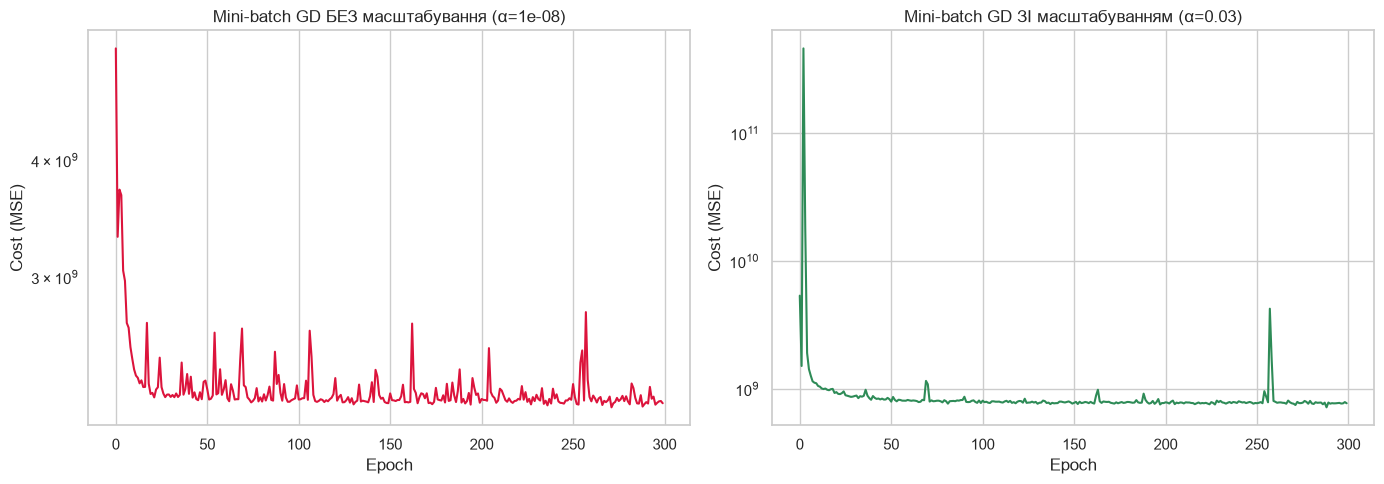

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_unscaled, color="crimson")
axes[0].set_title(f"Mini-batch GD БЕЗ масштабування (α={best_lr_unscaled})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cost (MSE)")
axes[0].set_yscale("log")

axes[1].plot(loss_scaled, color="seagreen")
axes[1].set_title(f"Mini-batch GD ЗІ масштабуванням (α={best_lr_scaled})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cost (MSE)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

**Висновок Експерименту А:**

- Найкраще знайдене α без масштабування: **1e-08**, зі масштабуванням: **0.03**.
- Фінальний Train loss без масштабування: **2 199 691 779.12**, зі масштабуванням:
  **773 619 494.57** — тобто модель без масштабування застрягла на рівні Cost майже
  у **2.8 раза вищому**, ніж модель зі стандартизацією, попри однакову кількість епох (300).
- Щоб уникнути розходження без масштабування, довелось зменшити α приблизно у
  **3 000 000 разів** (з 0.03 до 1e-08) — це прямий наслідок того, що ознаки на кшталт
  `Gr Liv Area` (діапазон 407–5642) чи `Year Built` (1872–2010) мають абсолютні значення
  на 2–4 порядки більші за стандартизовані (де всі ознаки ∈ приблизно [-3, 3]), а отже
  дають градієнти на порядки більшої величини — щоб компенсувати це й не спричинити
  вибух ваг, довелось пропорційно зменшити крок.
- Форма кривої без масштабування принципово інша: замість плавного монотонного
  спадання (як у scaled-варіанті) вона одразу після старту "провалюється" до рівня
  ~3–4×10⁹ і далі **шумно осцилює навколо цього рівня** протягом усіх 300 епох, так і
  не спускаючись суттєво нижче — модель фактично не встигає навчитись за відведений
  бюджет ітерацій. Scaled-варіант, навпаки, швидко (за перші ~10–20 епох) спускається
  до рівня ~7–8×10⁸ і залишається стабільним (за винятком одного короткого сплеску
  біля епохи ~260, вже описаного на Етапі 3).

**Геометричне пояснення, чому без масштабування GD працює гірше:** без
стандартизації масштаб ознак відрізняється на 2-3 порядки (наприклад, `Overall Qual`
∈ [1,10] проти `Gr Liv Area` ∈ [400,5600]), тому лінії рівня (contour) функції втрат
MSE в просторі ваг `w` мають форму сильно витягнутого еліпса, а не кола. Градієнтний
спуск рухається перпендикулярно до ліній рівня, тому на такому "яру" він змушений
робити зигзагоподібні кроки — рухається швидко вздовж короткої осі еліпса (де
градієнт по вазі, що відповідає малошкальній ознаці, дуже великий) і повільно вздовж
довгої осі, а єдиний загальний α змушений бути настільки малим, щоб не спричинити
розходження по "крутому" напрямку — через що збіжність по "пологому" напрямку стає
надзвичайно повільною. Це якраз і спостерігаємо на графіку: α=1e-08 достатньо
малий, щоб не вибухнути по "крутих" напрямках (типу `Gr Liv Area`), але настільки
малий, що по "пологих" напрямках модель практично не рухається за 300 епох.
Стандартизація робить контури Cost(w) близькими до кіл, тому градієнт вказує майже
точно в напрямку мінімуму з будь-якої точки, і один і той самий (значно більший) α
ефективно працює в усіх напрямках одразу.